# First Name: Jack
# Last Name: Kelly

# Import Libraries  

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats
import matplotlib.pyplot as plt

# Import Data

In [33]:
bottledata = pd.read_csv('Bottle.csv', low_memory=False)
pd.set_option('display.float_format', lambda x:'%f'%x)

# Data management 

In [35]:
sub2 = bottledata.copy()

#set a max to avoid outliers
sub2 = sub2[sub2['R_Depth'] < 1300]

#cut and relabel into categories for depth
sub2['DepthLevels'] = pd.cut(sub2['R_Depth'], [0, 50, 200, 500, 1300], labels = ['Shallow', 'Low Depth', 'Medium Depth', 'High Depth'])

#max o2sat is 214.1
#cut and relabel for o2sat (>100 = 'oversaturated')
sub2['SaturationLevels'] = pd.cut(sub2['O2Sat'], [0, 80, 120, 215], labels = ['Undersaturated', 'Normal', 'Oversaturated'])

#grab just the two variables and drop na
sub2 = sub2[['DepthLevels','SaturationLevels']]
sub2 = sub2.dropna(subset = ['DepthLevels','SaturationLevels'])

print(len(sub2))
sub2.head()

658761


,DepthLevels,SaturationLevels
2161,Shallow,Normal
2162,Shallow,Normal
2163,Shallow,Normal
2164,Shallow,Normal
2165,Shallow,Normal


# Chart/Plot

Text(0, 0.5, 'Count')

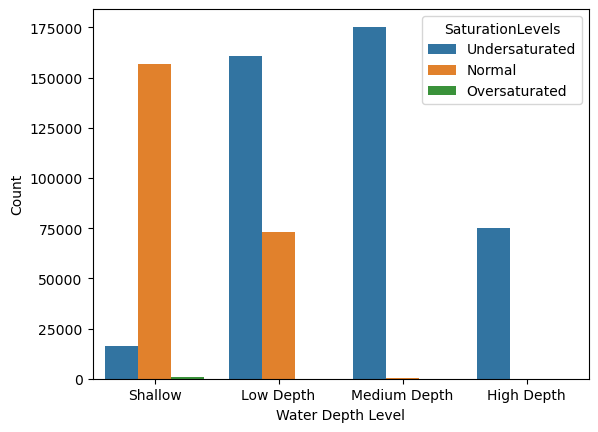

In [36]:
%matplotlib inline
sns.countplot(data=sub2, x='DepthLevels', hue='SaturationLevels')
plt.xlabel('Water Depth Level')
plt.ylabel('Count')

# CHI_Squared

In [42]:
#make contingency table
conttable = pd.crosstab(sub2['DepthLevels'], sub2['SaturationLevels'])
print(conttable)

SaturationLevels  Undersaturated  Normal  Oversaturated
DepthLevels                                            
Shallow                    16247  156548            965
Low Depth                 160858   73328             17
Medium Depth              175345     321              0
High Depth                 75132       0              0


In [43]:
#show chi values
print ('chi-square value, p value, expected counts')
chi1= scipy.stats.chi2_contingency(conttable)
print (chi1)

chi-square value, p value, expected counts
Chi2ContingencyResult(statistic=np.float64(372123.5178801957), pvalue=np.float64(0.0), dof=6, expected_freq=array([[1.12782403e+05, 6.07185773e+04, 2.59020069e+02],
       [1.52014140e+05, 8.18397385e+04, 3.49121071e+02],
       [1.14019530e+05, 6.13846087e+04, 2.61861300e+02],
       [4.87659270e+04, 2.62540755e+04, 1.11997559e+02]]))
